# Exploratory Data Analysis: Mercedes-Benz Used Car Prices (2005–2025, USA)

**Dataset:** [Mercedes-Benz Price Dataset 2005–2025 USA](https://www.kaggle.com/datasets/ibrahimshahrukh/mercedes-benz-price-dataset-2005-2025-usa)  

This notebook explores a dataset of Mercedes-Benz vehicles listed for sale in the United States over a 20-year span. The goal is to understand the structure, distributions, and relationships in the data before building a price prediction model.

**Central question:** What factors most strongly drive the price of a used Mercedes-Benz?

---

## 1. Setup & Data Loading

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import kagglehub
import os
import warnings

warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [96]:
path = kagglehub.dataset_download('ibrahimshahrukh/mercedes-benz-price-dataset-2005-2025-usa')
files = os.listdir(path)
print('Files in dataset:', files)

file_path = os.path.join(path, files[0])
df = pd.read_csv(file_path)
print(f'\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Files in dataset: ['mercedes_benz_listings_cleaned.csv']

Loaded: 108 rows x 13 columns


## 2. First Look at the Data

In [97]:
df.head()

,Vehicle_Name,Year,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Mileage_Category,Price_USD,Price_Category,Price_Per_Mile
0,2025 Mercedes-Benz AMG S 63 E 4MATIC,2025,1,AMG S 63,S 63,Other,1,1,9860,Low (< 20K),151900,Luxury (> $70K),15.405680
1,2025 Mercedes-Benz GLE 580 4MATIC,2025,1,GLE,E 580,SUV,0,1,3154,Low (< 20K),82975,Luxury (> $70K),26.307863
2,2025 Mercedes-Benz GLS 450 4MATIC,2025,1,GLS,S 450,SUV,0,1,15496,Low (< 20K),75500,Luxury (> $70K),4.872225
3,2025 Mercedes-Benz GLE 450e 4MATIC,2025,1,GLE,E 450,SUV,0,1,9303,Low (< 20K),67996,Premium ($40K-$70K),7.309040
4,2025 Mercedes-Benz GLE 450e 4MATIC,2025,1,GLE,E 450,SUV,0,1,17259,Low (< 20K),63928,Premium ($40K-$70K),3.704038


In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Vehicle_Name      108 non-null    str    
 1   Year              108 non-null    int64  
 2   Vehicle_Age       108 non-null    int64  
 3   Model_Series      108 non-null    str    
 4   Trim_Level        108 non-null    str    
 5   Body_Type         108 non-null    str    
 6   Is_AMG            108 non-null    int64  
 7   Is_4MATIC         108 non-null    int64  
 8   Mileage_Miles     108 non-null    int64  
 9   Mileage_Category  108 non-null    str    
 10  Price_USD         108 non-null    int64  
 11  Price_Category    108 non-null    str    
 12  Price_Per_Mile    108 non-null    float64
dtypes: float64(1), int64(6), str(6)
memory usage: 11.1 KB


In [99]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Vehicle_Name,108,94,2025 Mercedes-Benz GLA 250 4MATIC,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,108.0,NaN,NaN,NaN,2020.555556,3.816671,2005.0,2019.0,2022.0,2023.0,2025.0
Vehicle_Age,108.0,NaN,NaN,NaN,5.444444,3.816671,1.0,3.0,4.0,7.0,21.0
Model_Series,108,32,E-Class,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Trim_Level,108,29,Standard,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Body_Type,108,7,SUV,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_AMG,108.0,NaN,NaN,NaN,0.138889,0.347443,0.0,0.0,0.0,0.0,1.0
Is_4MATIC,108.0,NaN,NaN,NaN,0.685185,0.466607,0.0,0.0,1.0,1.0,1.0
Mileage_Miles,108.0,NaN,NaN,NaN,47528.731481,33832.988723,628.0,19769.0,42701.5,70671.25,186500.0
Mileage_Category,108,4,High (50K-100K),39,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Initial observations:**
- `Price_USD` is our target variable.
- `Year` and `Mileage_Miles` are the main continuous predictors.
- `Body_Type` and `Model_Series` are categorical variables that likely have strong price signals.
- Worth checking for extreme price outliers (e.g., data entry errors) and whether mileage has a realistic range.

## 3. Missing Values & Data Quality

In [100]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print('No missing values found.')
else:
    print('Columns with missing values (%):')
    print(missing.round(2).to_string())

    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.4)))
    missing.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

No missing values found.


In [101]:
# Check for duplicates
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.2f}%)')

# Basic sanity checks on key numeric fields
print(f'\nPrice_USD range: ${df["Price_USD"].min():,.0f} — ${df["Price_USD"].max():,.0f}')
print(f'Mileage_Miles range: {df["Mileage_Miles"].min():,.0f} — {df["Mileage_Miles"].max():,.0f}')
print(f'Year range: {df["Year"].min()} — {df["Year"].max()}')

Duplicate rows: 0 (0.00%)

Price_USD range: $6,420 — $169,995
Mileage_Miles range: 628 — 186,500
Year range: 2005 — 2025


## 4. Target Variable: Price Distribution

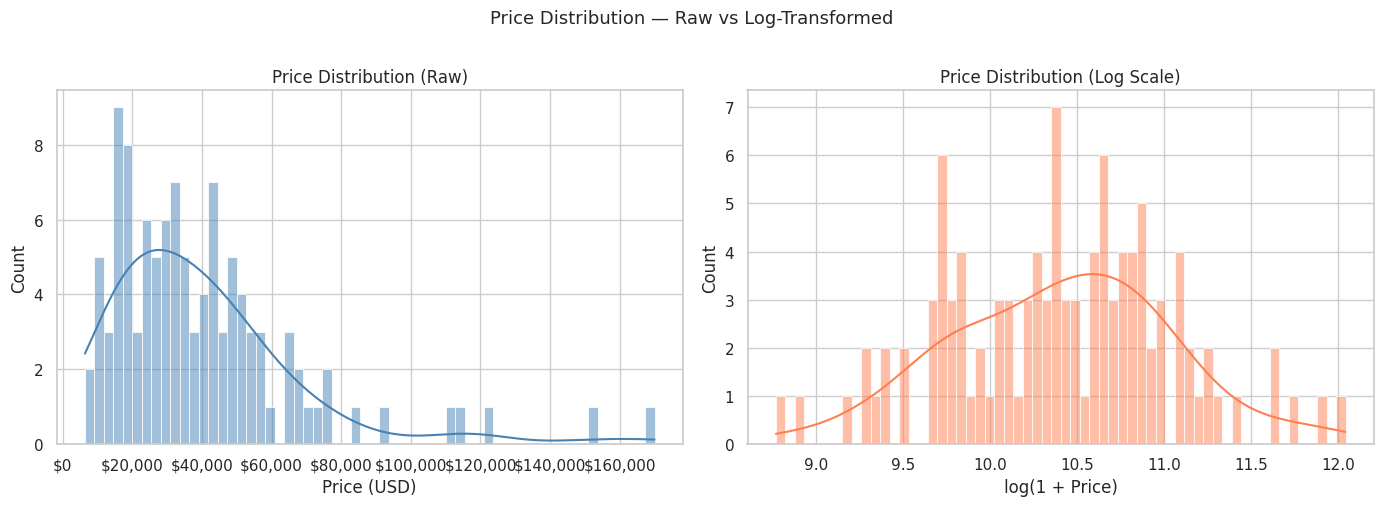

Skewness (raw):   2.097
Skewness (log):   -0.019
Median price:     $33,499
Mean price:       $40,310


In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
sns.histplot(df['Price_USD'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Log-transformed price
log_price = np.log1p(df['Price_USD'])
sns.histplot(log_price, bins=60, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xlabel('log(1 + Price)')

plt.suptitle('Price Distribution — Raw vs Log-Transformed', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Skewness (raw):   {df["Price_USD"].skew():.3f}')
print(f'Skewness (log):   {log_price.skew():.3f}')
print(f'Median price:     ${df["Price_USD"].median():,.0f}')
print(f'Mean price:       ${df["Price_USD"].mean():,.0f}')

The raw price distribution is right-skewed, which is typical of vehicle pricing — a small number of high-end listings (AMG, G-Wagon, Maybach) pull the mean above the median. The log-transformed version is close to normal, which suggests that **a regression model would benefit from predicting log(price)** rather than price directly.

## 5. Numerical Features: Year and Mileage

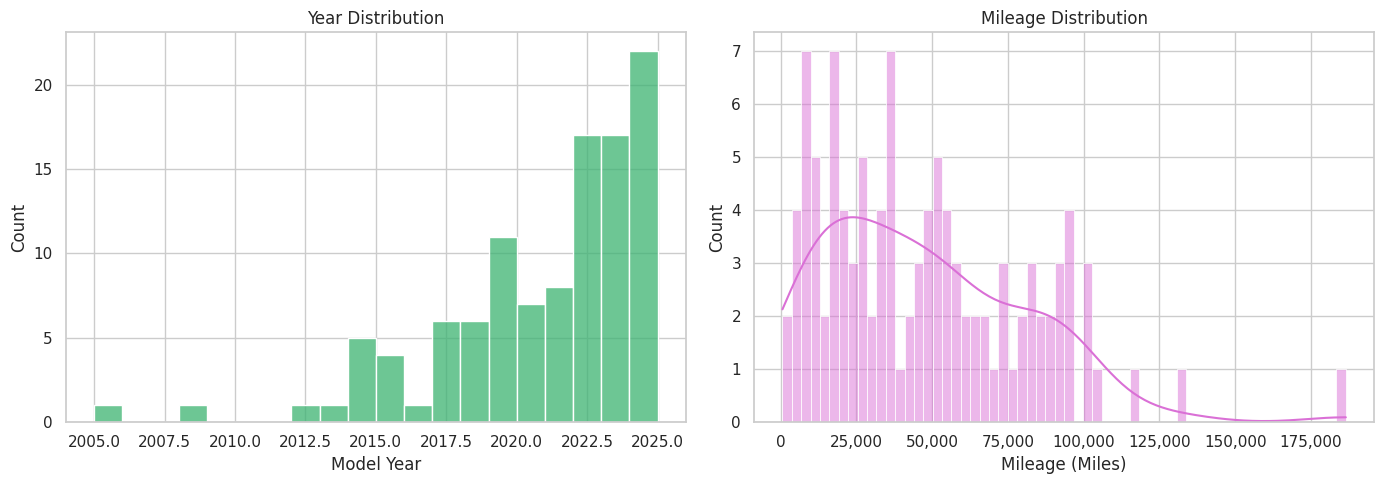

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Year'], bins=20, ax=axes[0], color='mediumseagreen', kde=False)
axes[0].set_title('Year Distribution')
axes[0].set_xlabel('Model Year')

sns.histplot(df['Mileage_Miles'], bins=60, kde=True, ax=axes[1], color='orchid')
axes[1].set_title('Mileage Distribution')
axes[1].set_xlabel('Mileage (Miles)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

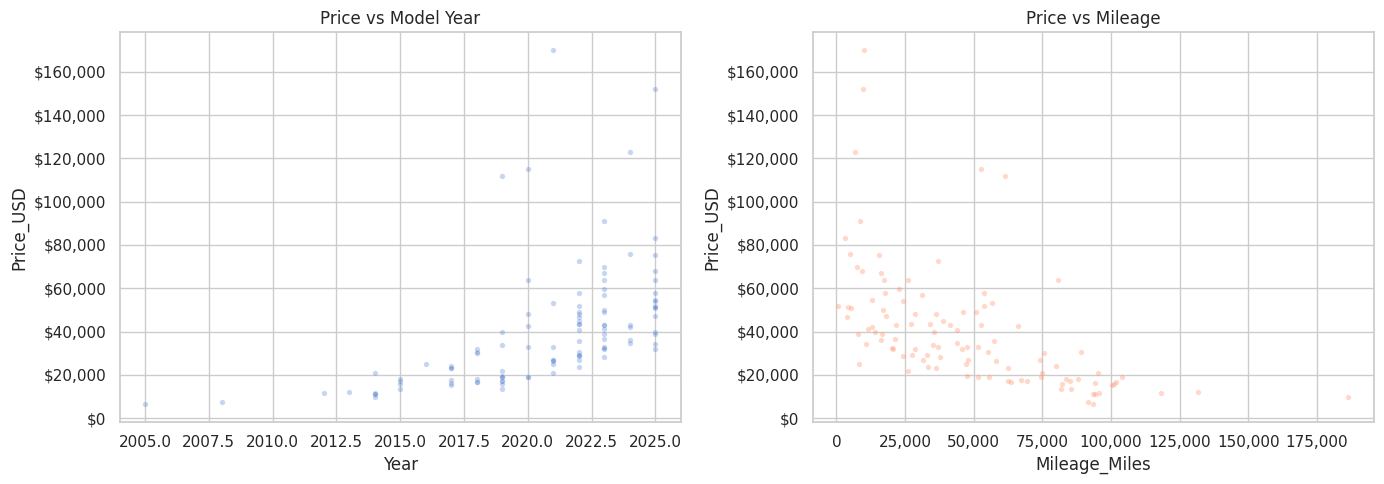

In [104]:
# Compute vehicle age and add it to the dataframe
current_year = 2025
df['Age'] = current_year - df['Year']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='Year', y='Price_USD', data=df, ax=axes[0], alpha=0.3, s=15)
axes[0].set_title('Price vs Model Year')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.scatterplot(x='Mileage_Miles', y='Price_USD', data=df, ax=axes[1], alpha=0.3, s=15, color='coral')
axes[1].set_title('Price vs Mileage')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

**Observations:**
- As expected, newer cars command higher prices. The relationship is clearest in the post-2015 range.
- Mileage has a clear negative correlation with price, but there is significant vertical spread — indicating that **model type and condition matter a lot beyond just mileage**.
- There are a few very high-mileage observations (>300k miles) that may be outliers worth investigating.

## 6. Outlier Detection

In [105]:
def iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

for col in ['Price_USD', 'Mileage_Miles']:
    mask, lo, hi = iqr_outliers(df[col])
    n = mask.sum()
    print(f'{col}: {n} outliers ({n/len(df)*100:.1f}%) — IQR fence [{lo:,.0f}, {hi:,.0f}]')

Price_USD: 5 outliers (4.6%) — IQR fence [-23,856, 94,704]
Mileage_Miles: 1 outliers (0.9%) — IQR fence [-56,584, 147,025]


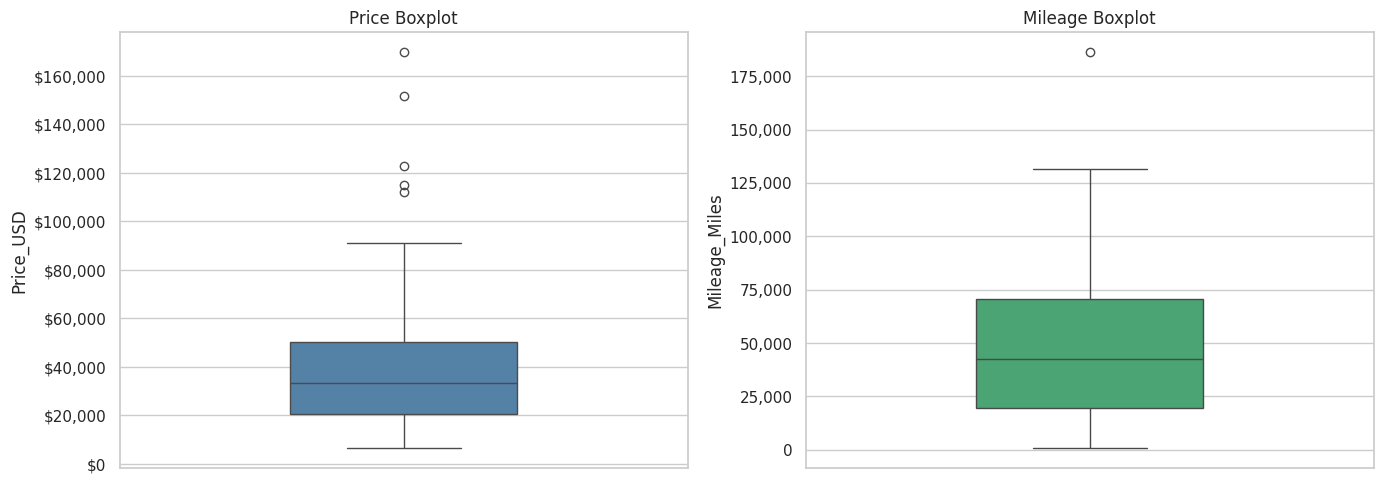

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['Price_USD'], ax=axes[0], color='steelblue', width=0.4)
axes[0].set_title('Price Boxplot')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.boxplot(y=df['Mileage_Miles'], ax=axes[1], color='mediumseagreen', width=0.4)
axes[1].set_title('Mileage Boxplot')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [107]:
# Look at the most extreme price cases
print('=== Top 10 Most Expensive Listings ===')
print(df.nlargest(10, 'Price_USD')[['Year', 'Model_Series', 'Body_Type', 'Mileage_Miles', 'Price_USD']].to_string(index=False))

print('\n=== 10 Cheapest Listings ===')
print(df.nsmallest(10, 'Price_USD')[['Year', 'Model_Series', 'Body_Type', 'Mileage_Miles', 'Price_USD']].to_string(index=False))

=== Top 10 Most Expensive Listings ===
 Year Model_Series       Body_Type  Mileage_Miles  Price_USD
 2021     AMG G 63           Other           9938     169995
 2025     AMG S 63           Other           9860     151900
 2024    AMG GT 55 Sports/Roadster           6937     122881
 2020     AMG S 65           Other          52802     114995
 2019     AMG G 63           Other          61559     111990
 2023      S-Class           Sedan           8735      90993
 2025          GLE             SUV           3154      82975
 2024          GLS             SUV           4932      75950
 2025          GLS             SUV          15496      75500
 2022      S-Class           Sedan          36964      72800

=== 10 Cheapest Listings ===
 Year Model_Series Body_Type  Mileage_Miles  Price_USD
 2005    CLK-Class     Coupe          93350       6420
 2008      E-Class     Sedan          91577       7490
 2014      E-Class     Sedan         186500       9650
 2014      M-Class       SUV          94

High-price outliers are likely legitimate luxury/performance models (e.g., SLS AMG, G63, Maybach S-Class). Very low-price listings may reflect high-mileage older vehicles or data entry errors — worth filtering during modeling.

## 7. Categorical Feature Analysis

In [108]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

for col in cat_cols:
    print(f'\n{col}: {df[col].nunique()} unique values')
    print(df[col].value_counts().head(10).to_string())

Categorical columns: ['Vehicle_Name', 'Model_Series', 'Trim_Level', 'Body_Type', 'Mileage_Category', 'Price_Category']

Vehicle_Name: 94 unique values
Vehicle_Name
2025 Mercedes-Benz GLA 250 4MATIC          3
2023 Mercedes-Benz EQS 580 4MATIC          3
2022 Mercedes-Benz CLS 450 Base            3
2025 Mercedes-Benz GLE 450e 4MATIC         2
2025 Mercedes-Benz AMG GLC 43 4MATIC       2
2023 Mercedes-Benz E-Class 4MATIC          2
2023 Mercedes-Benz C-Class C 300 4MATIC    2
2023 Mercedes-Benz GLA 250 4MATIC          2
2019 Mercedes-Benz GLA 250 4MATIC          2
2019 Mercedes-Benz GLC 300 4MATIC          2

Model_Series: 32 unique values
Model_Series
E-Class       16
GLE           11
GLA           10
GLC            8
GLS            7
C-Class        6
S-Class        5
Unknown        5
AMG GLC 43     3
GLB            3

Trim_Level: 29 unique values
Trim_Level
Standard    18
C 300       13
E 350       11
GLA 250     11
S 450        9
S 580        7
E 450        5
C 43         4
E 300     

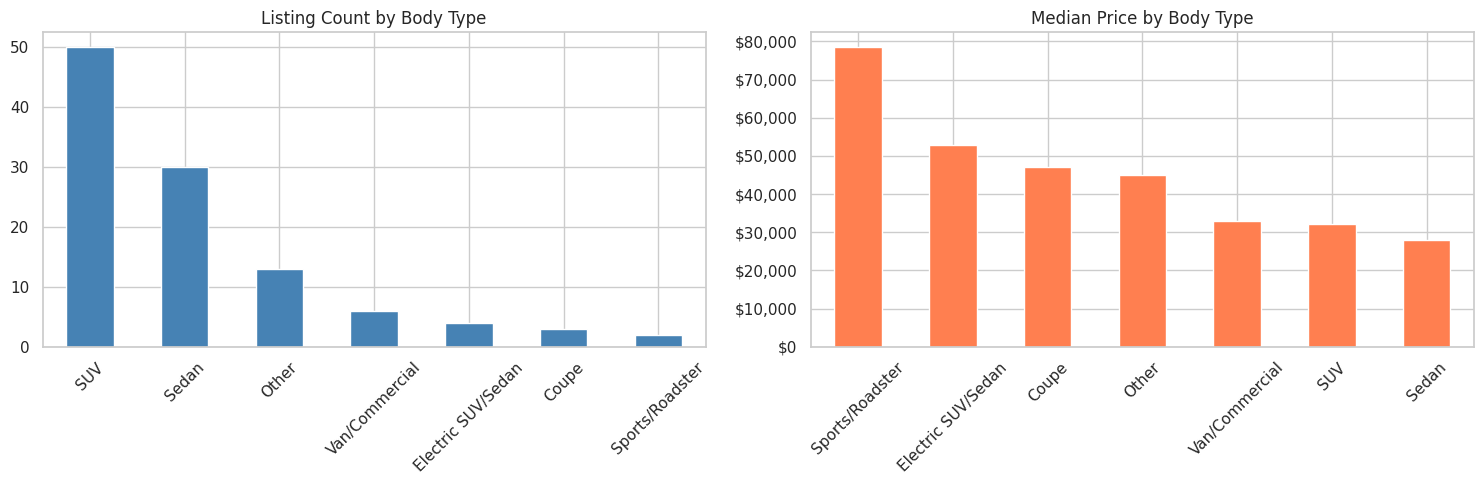

In [109]:
# Body Type distribution and price
body_counts = df['Body_Type'].value_counts()
body_price = df.groupby('Body_Type')['Price_USD'].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

body_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Listing Count by Body Type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

body_price.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Median Price by Body Type')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

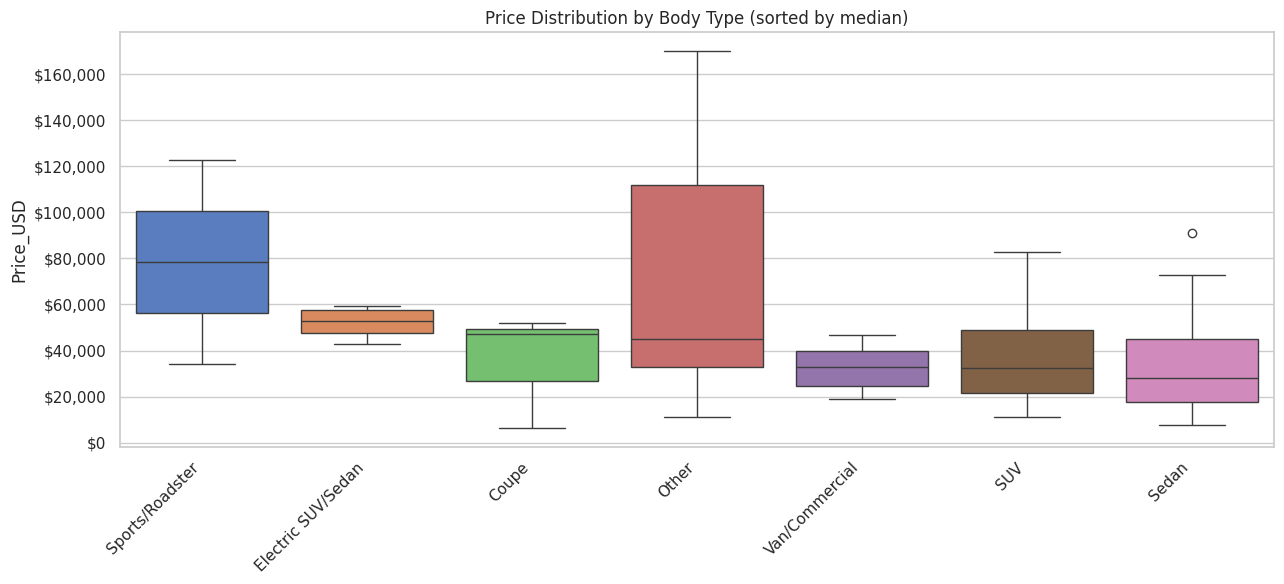

In [110]:
# Price distribution by body type (boxplot)
order = df.groupby('Body_Type')['Price_USD'].median().sort_values(ascending=False).index

plt.figure(figsize=(13, 6))
sns.boxplot(x='Body_Type', y='Price_USD', data=df, order=order, palette='muted')
plt.title('Price Distribution by Body Type (sorted by median)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

Min count threshold used: 2.0
Series in plot: 15


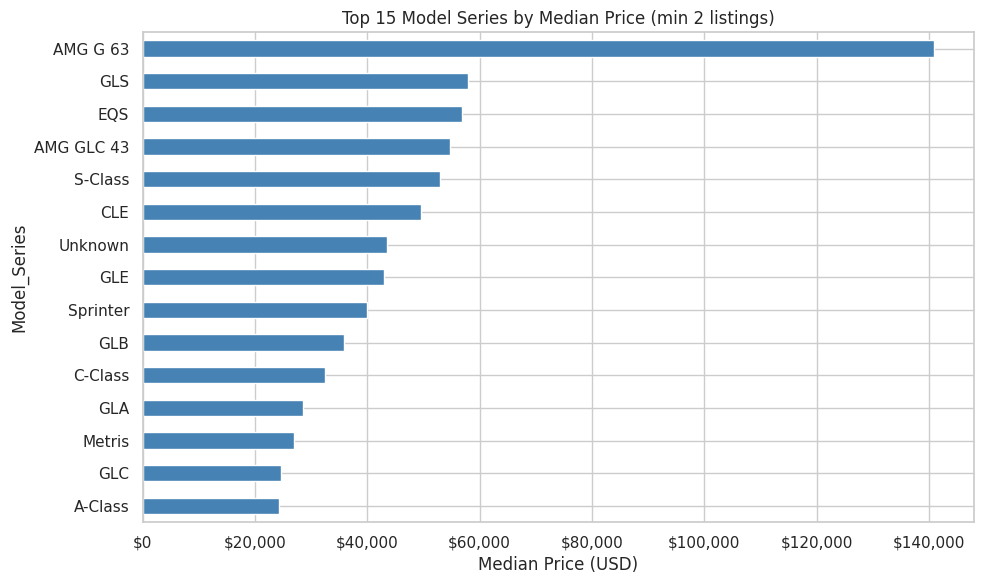

In [111]:
# Top 15 Model Series by median price
min_count = min(20, df['Model_Series'].value_counts().quantile(0.5))

top_series = (
    df.groupby('Model_Series')
    .agg(count=('Price_USD', 'count'), median_price=('Price_USD', 'median'))
    .query(f'count >= {min_count}')
    .sort_values('median_price', ascending=False)
    .head(15)
)

print(f'Min count threshold used: {min_count}')
print(f'Series in plot: {len(top_series)}')

fig, ax = plt.subplots(figsize=(10, 6))
top_series['median_price'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top 15 Model Series by Median Price (min {min_count:.0f} listings)')
ax.set_xlabel('Median Price (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

**Observations:**
- Body type is a meaningful price signal: SUVs and convertibles tend to command premium prices.
- Model series shows strong price stratification. The G-Class, S-Class, and AMG variants are at the top.
- Some model series have very few listings — these may need to be grouped or dropped when modeling.

## 8. Correlation Analysis

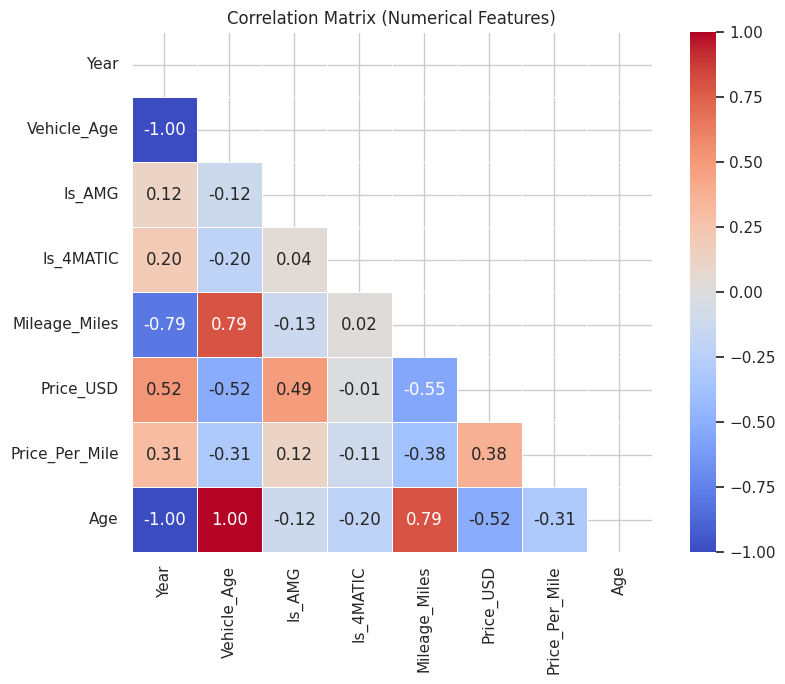

In [112]:
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title('Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.show()

In [113]:
# Correlation with Price_USD specifically
price_corr = corr['Price_USD'].drop('Price_USD').sort_values(key=abs, ascending=False)
print('Correlation with Price_USD:')
print(price_corr.to_string())

Correlation with Price_USD:
Mileage_Miles    -0.547850
Year              0.517229
Vehicle_Age      -0.517229
Age              -0.517229
Is_AMG            0.488209
Price_Per_Mile    0.380353
Is_4MATIC        -0.012862


## 9. Price Trends Over Time

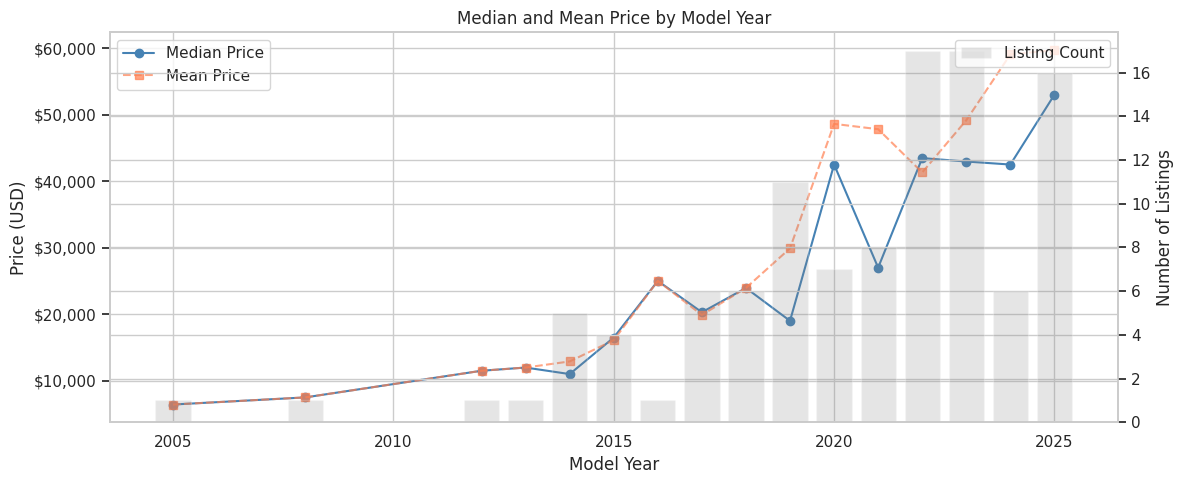

In [114]:
# How do median prices vary by year?
yearly = df.groupby('Year')['Price_USD'].agg(['median', 'mean', 'count']).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(yearly['Year'], yearly['median'], marker='o', label='Median Price', color='steelblue')
ax1.plot(yearly['Year'], yearly['mean'], marker='s', linestyle='--', label='Mean Price', color='coral', alpha=0.7)
ax1.set_ylabel('Price (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_xlabel('Model Year')
ax1.set_title('Median and Mean Price by Model Year')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(yearly['Year'], yearly['count'], alpha=0.2, color='grey', label='Listing Count')
ax2.set_ylabel('Number of Listings')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

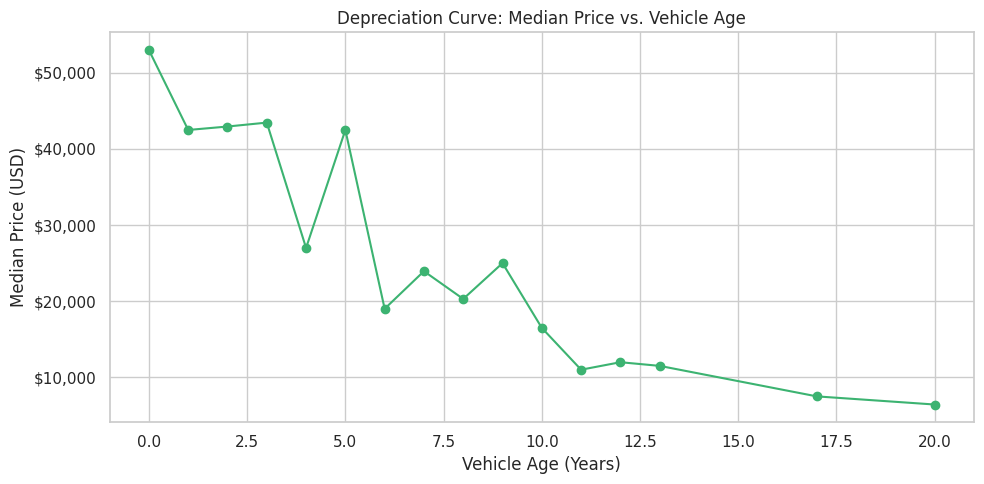

In [115]:
# Depreciation curve: how fast does price drop with age?
age_price = df.groupby('Age')['Price_USD'].median().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(age_price['Age'], age_price['Price_USD'], marker='o', color='mediumseagreen')
plt.xlabel('Vehicle Age (Years)')
plt.ylabel('Median Price (USD)')
plt.title('Depreciation Curve: Median Price vs. Vehicle Age')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

The depreciation curve shows the steepest price drop in the first ~5 years, flattening out afterwards. This is consistent with the known behavior of luxury vehicle depreciation in the US market.

## 10. Mileage–Price Relationship by Body Type

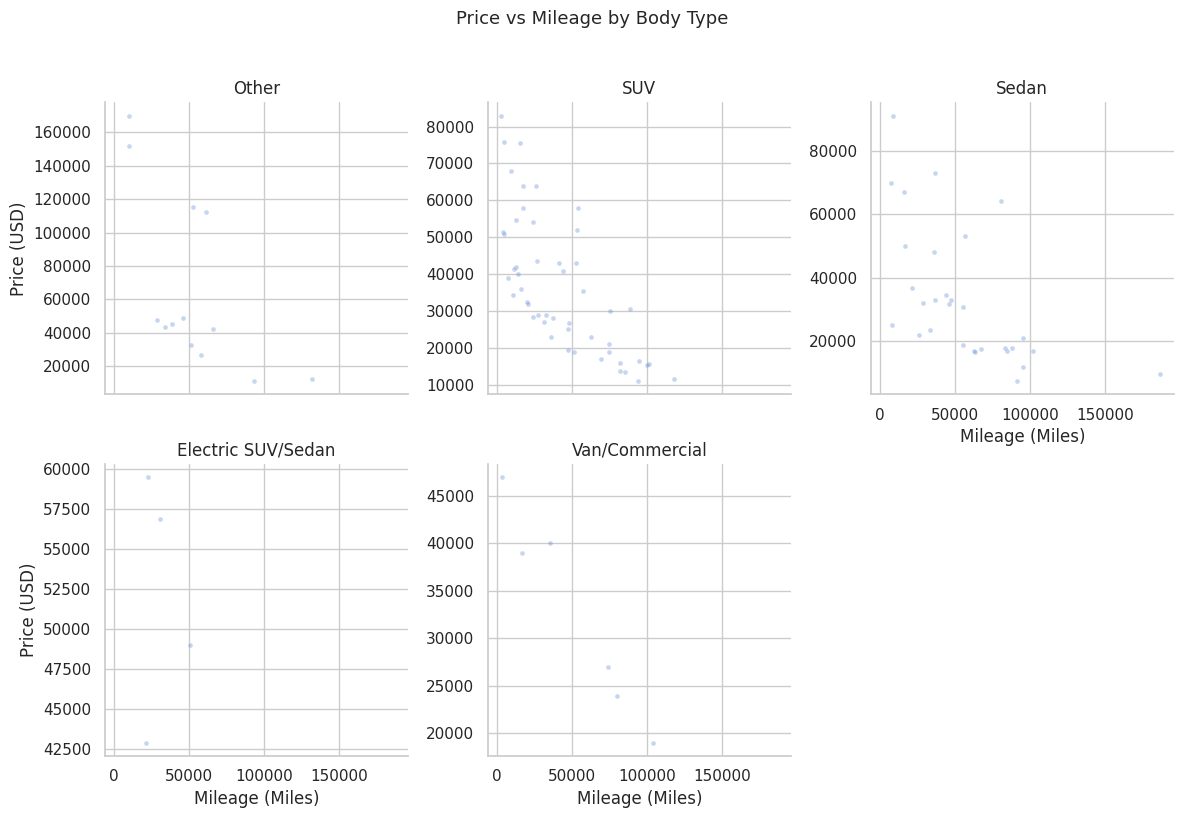

In [116]:
# Limit to top 5 body types to keep the chart readable
top_bodies = df['Body_Type'].value_counts().head(5).index
df_top = df[df['Body_Type'].isin(top_bodies)]

g = sns.FacetGrid(df_top, col='Body_Type', col_wrap=3, height=4, sharey=False)
g.map(sns.scatterplot, 'Mileage_Miles', 'Price_USD', alpha=0.3, s=12)
g.set_axis_labels('Mileage (Miles)', 'Price (USD)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Price vs Mileage by Body Type', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 11. Checking Other Categorical Variables

Vehicle_Name: 94 unique values — too many to visualize directly, skipping


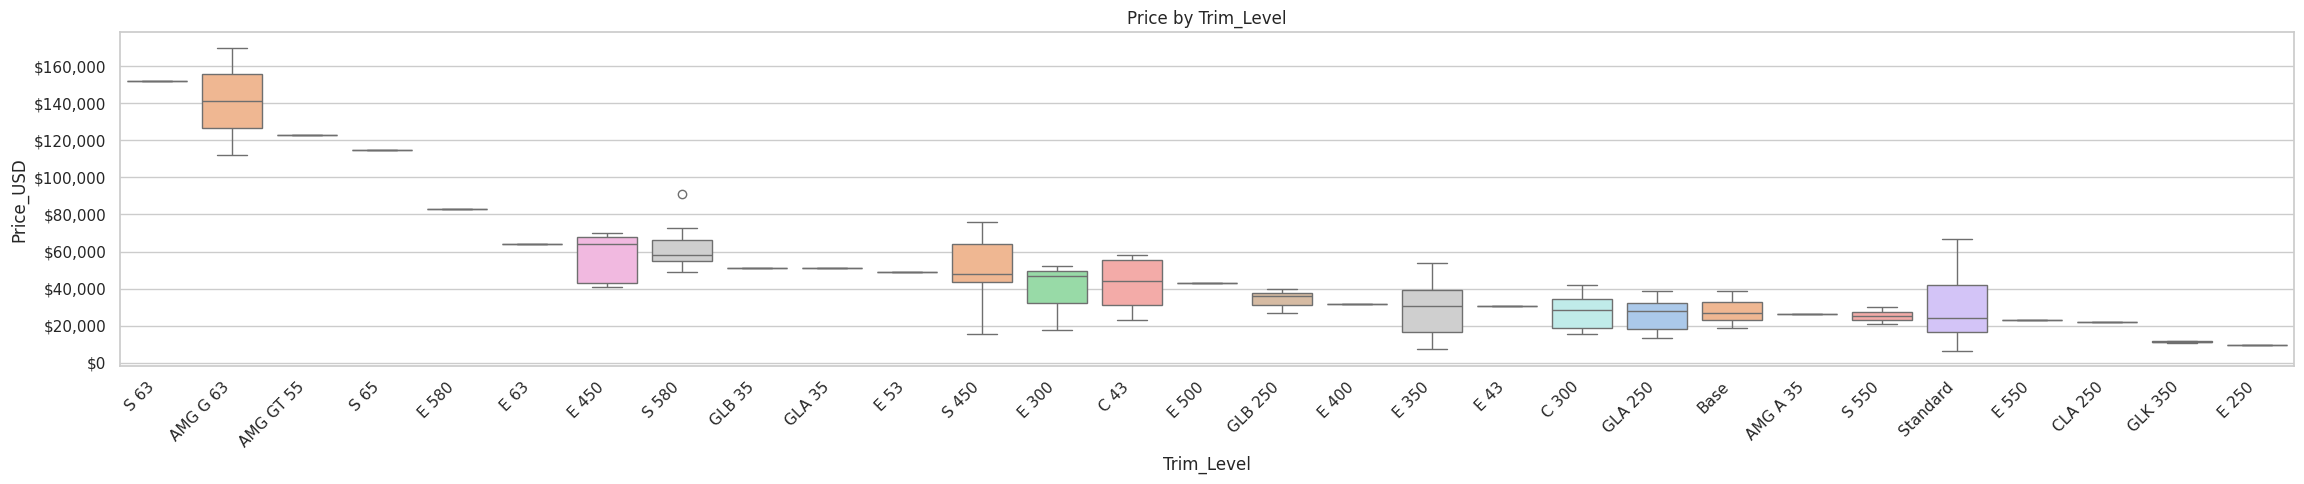

Trim_Level
S 63         $151,900
AMG G 63     $140,992
AMG GT 55    $122,881
S 65         $114,995
E 580         $82,975
E 63          $63,995
E 450         $63,928
S 580         $58,000
GLB 35        $51,399
GLA 35        $50,974
E 53          $48,989
S 450         $47,881
E 300         $46,995
C 43          $44,346
E 500         $42,881
GLB 250       $35,900
E 400         $31,881
E 350         $30,692
E 43          $30,498
C 300         $28,490
GLA 250       $28,154
Base          $26,995
AMG A 35      $26,500
S 550         $25,438
Standard      $24,474
E 550         $22,998
CLA 250       $21,992
GLK 350       $11,488
E 250          $9,650 



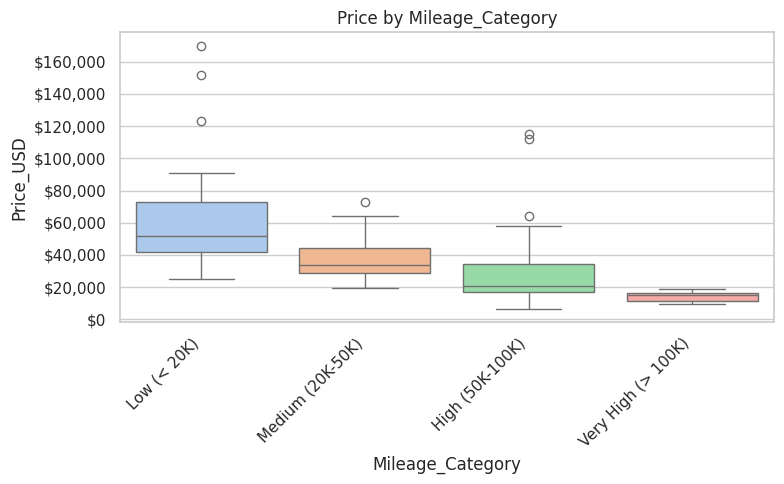

Mileage_Category
Low (< 20K)           $51,998
Medium (20K-50K)      $33,998
High (50K-100K)       $20,990
Very High (> 100K)    $15,400 



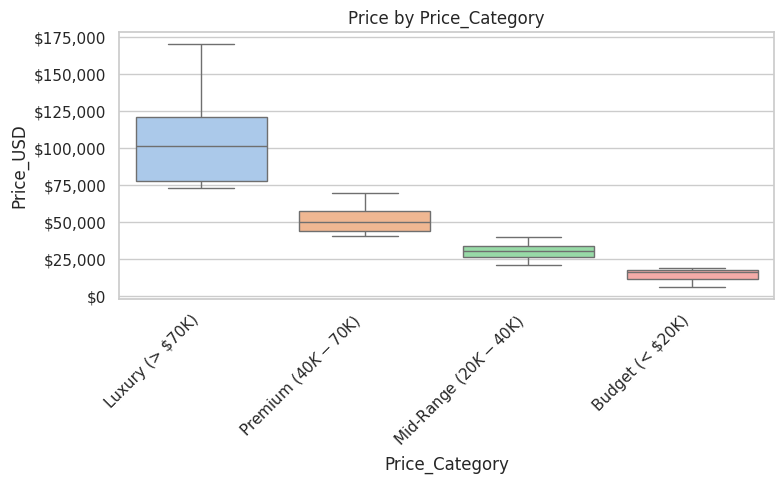

Price_Category
Luxury (> $70K)          $101,492
Premium ($40K-$70K)       $50,487
Mid-Range ($20K-$40K)     $30,498
Budget (< $20K)           $16,364 



In [117]:
# Investigate any remaining categorical columns that might be relevant
remaining_cats = [c for c in cat_cols if c not in ['Body_Type', 'Model_Series']]

for col in remaining_cats:
    n_unique = df[col].nunique()
    if n_unique > 30:
        print(f'{col}: {n_unique} unique values — too many to visualize directly, skipping')
        continue

    order = df.groupby(col)['Price_USD'].median().sort_values(ascending=False).index

    plt.figure(figsize=(max(8, n_unique * 0.8), 5))
    sns.boxplot(x=col, y='Price_USD', data=df, order=order, palette='pastel')
    plt.title(f'Price by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.tight_layout()
    plt.show()

    grp = df.groupby(col)['Price_USD'].median().sort_values(ascending=False)
    print(grp.apply(lambda x: f'${x:,.0f}').to_string(), '\n')

## 12. Feature Engineering — Initial Ideas

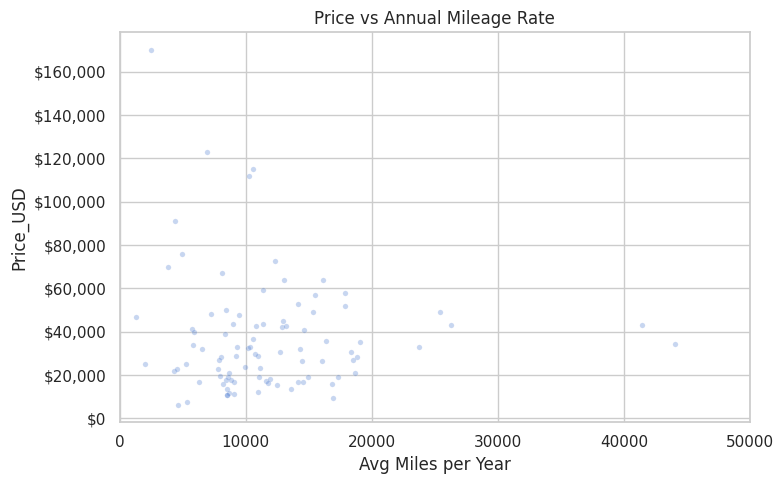

Correlation (Miles_Per_Year vs Price): -0.076


In [118]:
# Age is already computed. Let's also look at mileage per year as a proxy for usage intensity.
df['Miles_Per_Year'] = df['Mileage_Miles'] / df['Age'].replace(0, np.nan)

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Miles_Per_Year', y='Price_USD', data=df, alpha=0.3, s=15)
plt.xlim(0, 50000)   # filter extreme cases for readability
plt.title('Price vs Annual Mileage Rate')
plt.xlabel('Avg Miles per Year')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print(f'Correlation (Miles_Per_Year vs Price): {df[["Miles_Per_Year", "Price_USD"]].corr().iloc[0,1]:.3f}')

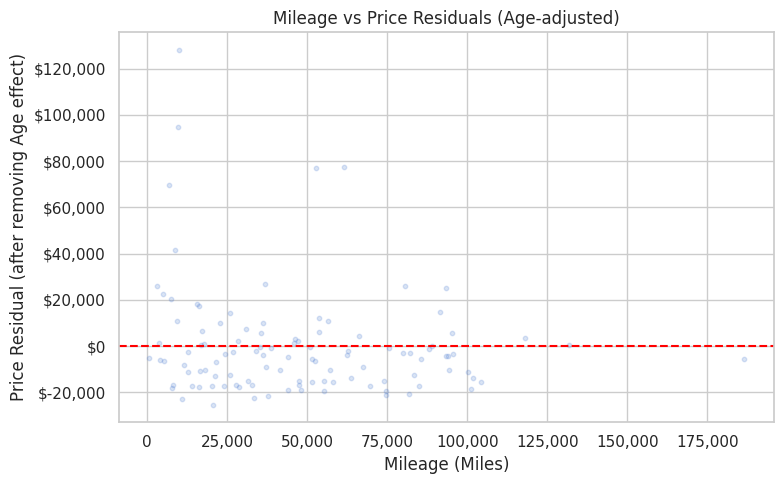

Correlation of Mileage with Age-adjusted Price: -0.163
=> Mileage has independent predictive power beyond vehicle age.


In [120]:
# Is there a meaningful interaction between age and mileage?
# We can check this by looking at residuals after removing the age effect.

from sklearn.linear_model import LinearRegression

clean = df[['Age', 'Mileage_Miles', 'Price_USD']].dropna()

X_age = clean[['Age']]
y = clean['Price_USD']

model = LinearRegression().fit(X_age, y)
residuals = y - model.predict(X_age)

plt.figure(figsize=(8, 5))
plt.scatter(clean['Mileage_Miles'], residuals, alpha=0.2, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Mileage (Miles)')
plt.ylabel('Price Residual (after removing Age effect)')
plt.title('Mileage vs Price Residuals (Age-adjusted)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

corr_resid = np.corrcoef(clean['Mileage_Miles'], residuals)[0, 1]
print(f'Correlation of Mileage with Age-adjusted Price: {corr_resid:.3f}')
print('=> Mileage has independent predictive power beyond vehicle age.')

Even after controlling for vehicle age, mileage still correlates negatively with price. This confirms that **both age and mileage carry independent information** and should both be included as features in any predictive model.

## 13. Summary of Findings

### Key Observations

1. **Price distribution is right-skewed.** A log transformation brings it close to normal, which is helpful for regression modeling.

2. **Year and mileage are the strongest numerical predictors.** Newer vehicles and lower mileage both correlate strongly with higher price. Importantly, mileage carries information *beyond* what vehicle age alone captures.

3. **Model series is a highly informative categorical variable.** The G-Class, Maybach, and AMG variants sit in a premium tier. Model series alone can explain a large portion of price variance.

4. **Body type matters.** SUVs and convertibles tend to command higher prices; sedans and coupes show wider spread.

5. **Depreciation is non-linear.** The steepest drop occurs in the first 1–5 years; older vehicles hold value more steadily — a pattern worth encoding (e.g., log(age) as a feature).

6. **Outliers exist but appear legitimate.** Extreme prices correspond to genuine low-volume, high-performance models. A robust modeling approach (e.g., quantile regression or outlier-robust loss) may be warranted.

### Directions for the Final Project

- **Price prediction model:** Predict `log(Price_USD)` using Year, Mileage, Model_Series, Body_Type, and any other available categorical variables. Gradient boosting (XGBoost/LightGBM) is a natural first choice given the mix of numerical and high-cardinality categorical features.

- **Feature engineering:** Derived features like `Age`, `Miles_Per_Year`, and interaction terms (e.g., `Age × Body_Type`) are worth testing.

- **Depreciation modeling:** Fit a depreciation curve per model series to quantify which models hold their value best — this is directly useful as a standalone analysis.

- **Anomaly detection:** Identify listings priced significantly below market value (potential deals), which has a practical application in used car purchasing.